In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import plotly.express as px


In [3]:
users_data = pd.read_csv("../data/raw/users_data.csv")

In [4]:
transactions_data = pd.read_csv("../data/processed/transactions_train.csv")

In [5]:
users_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 218.9+ KB


In [6]:
users_data.isna().sum()

id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64

## Check users data features

In [7]:
users_data.describe()

,id,current_age,retirement_age,birth_year,birth_month,latitude,longitude,credit_score,num_credit_cards
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,45.391500,66.237500,1973.803000,6.439000,37.389225,-91.554765,709.734500,3.073000
std,577.494589,18.414092,3.628867,18.421234,3.565338,5.114324,16.283293,67.221949,1.637379
min,0.000000,18.000000,50.000000,1918.000000,1.000000,20.880000,-159.410000,480.000000,1.000000
25%,499.750000,30.000000,65.000000,1961.000000,3.000000,33.837500,-97.395000,681.000000,2.000000
50%,999.500000,44.000000,66.000000,1975.000000,7.000000,38.250000,-86.440000,711.500000,3.000000
75%,1499.250000,58.000000,68.000000,1989.000000,10.000000,41.200000,-80.130000,753.000000,4.000000
max,1999.000000,101.000000,79.000000,2002.000000,12.000000,61.200000,-68.670000,850.000000,9.000000


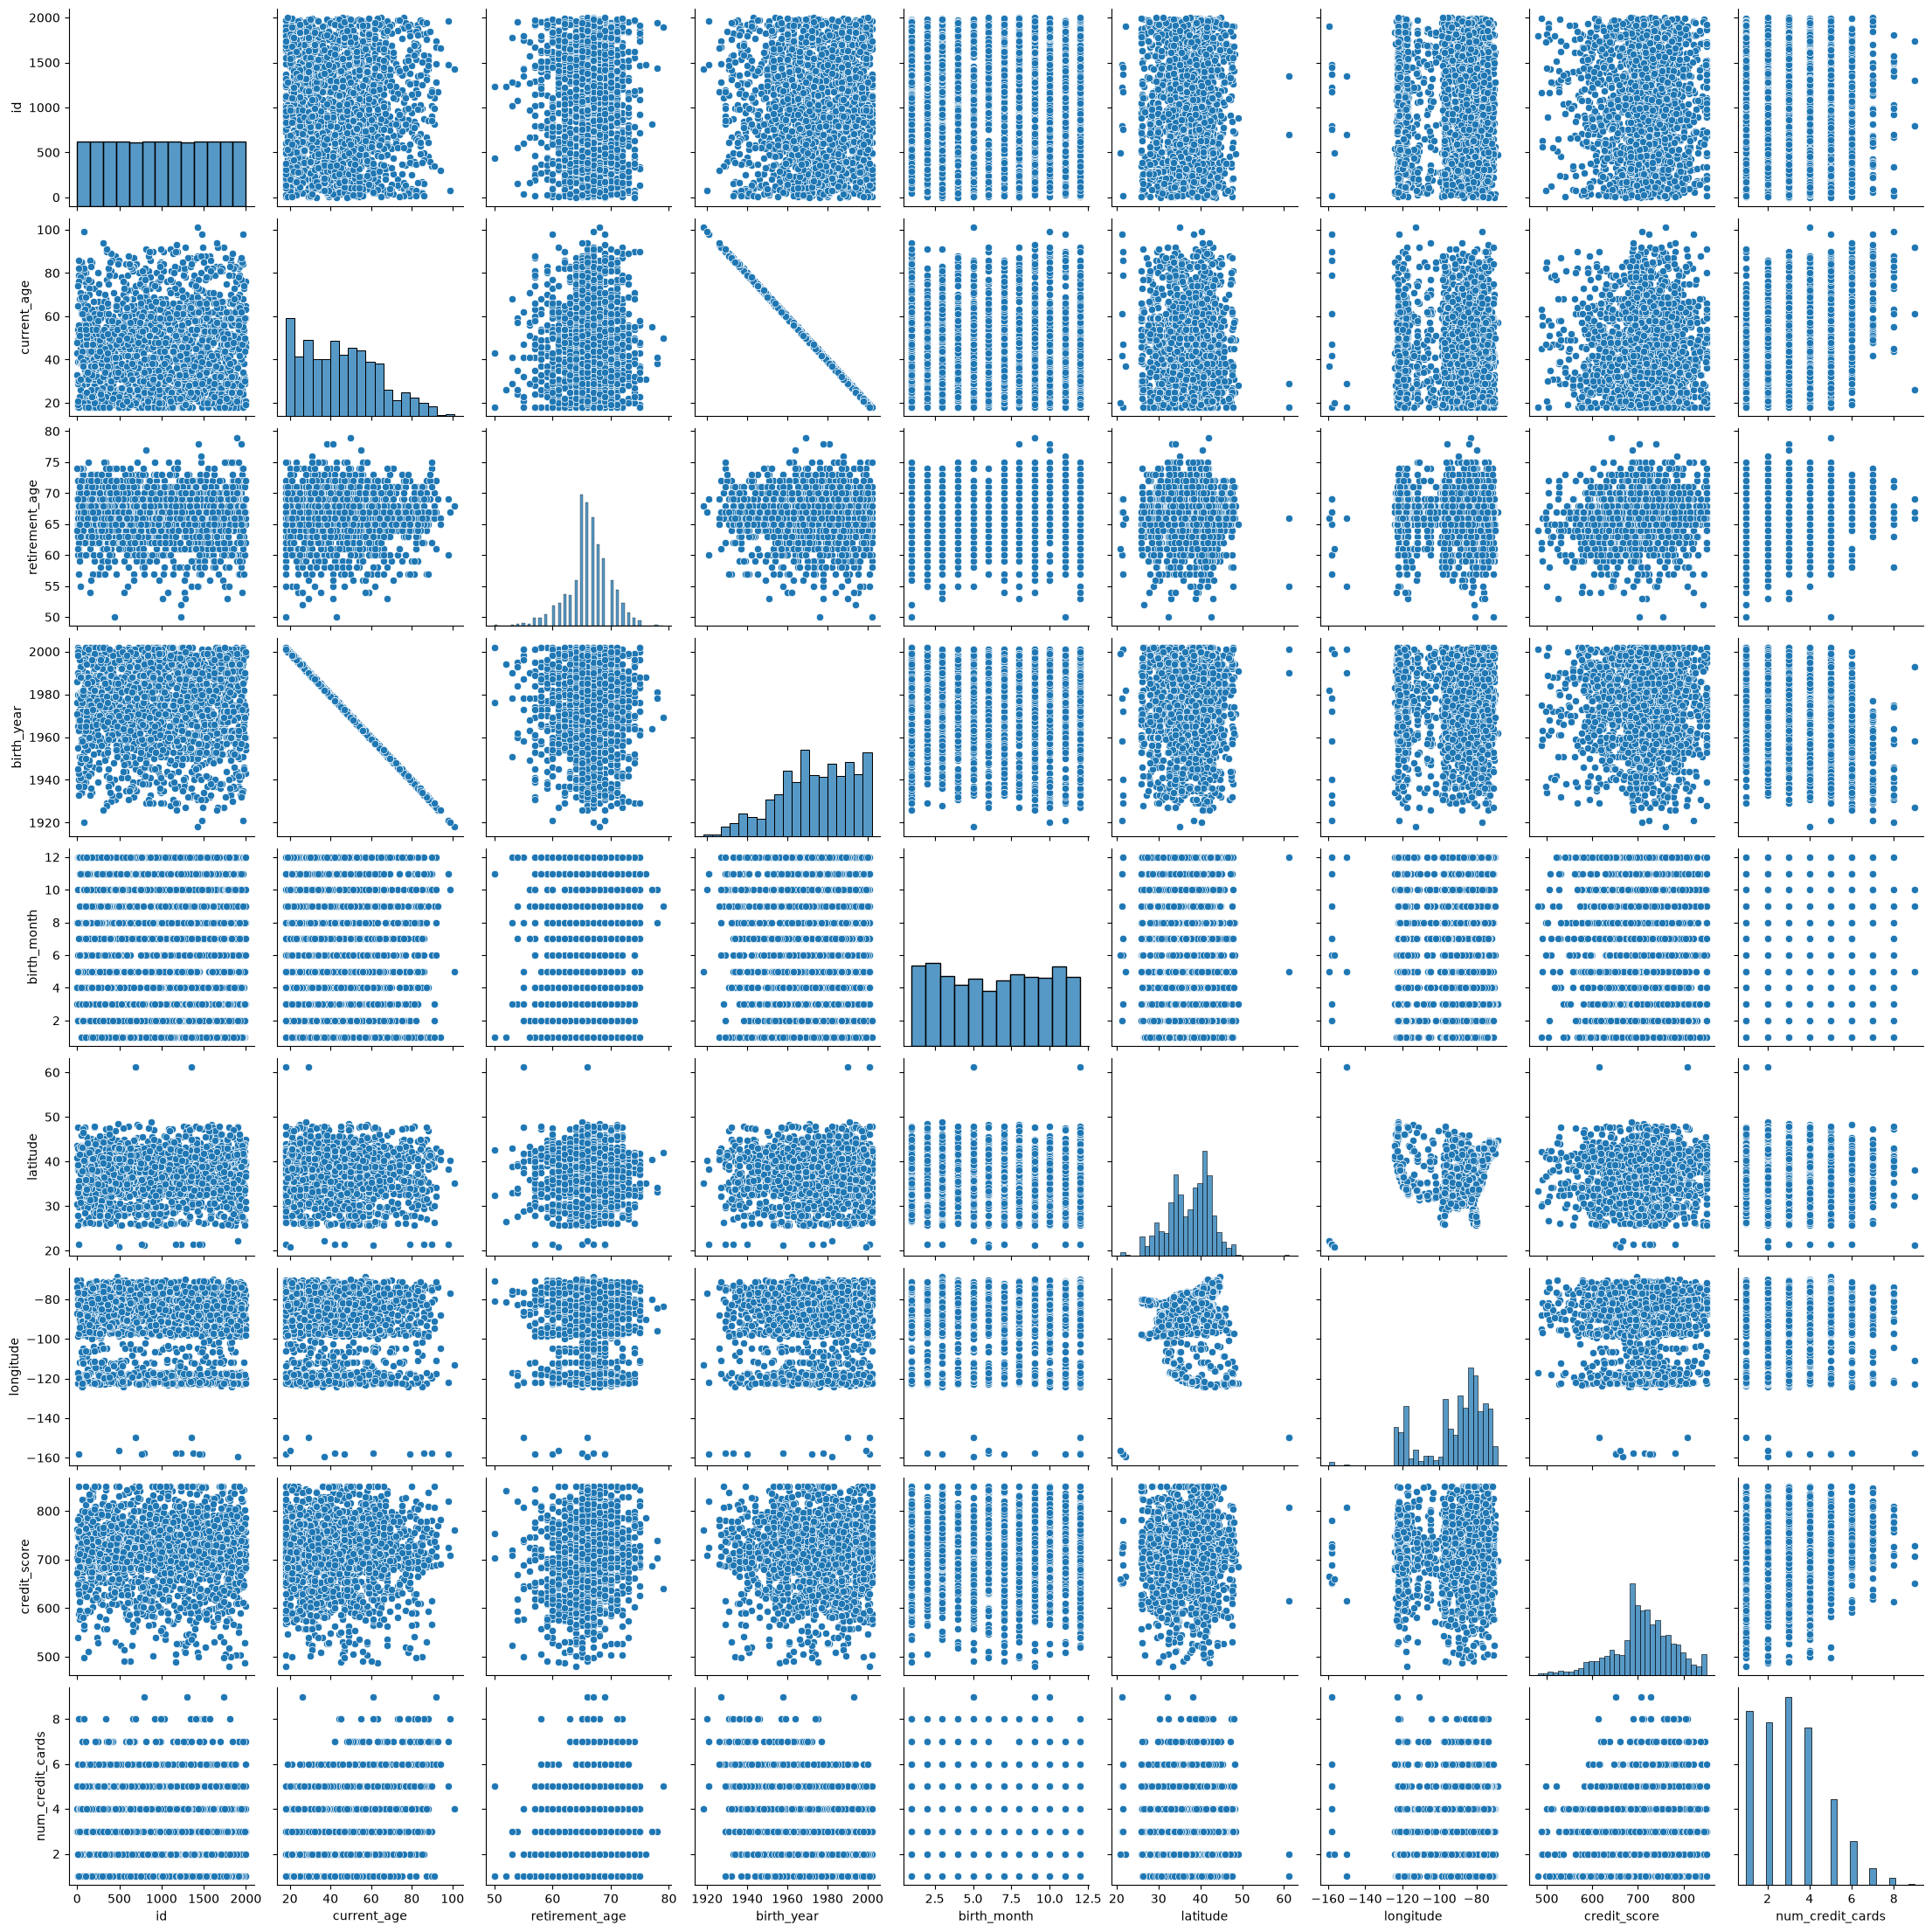

In [8]:
sns.pairplot(data=users_data)

## Combine with transactions

In [9]:
users_data.rename(columns={"id":"client_id"}, inplace=True)
users_data.columns

Index(['client_id', 'current_age', 'retirement_age', 'birth_year',
       'birth_month', 'gender', 'address', 'latitude', 'longitude',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards'],
      dtype='object')

In [10]:
print("Transactions data before: ", transactions_data.shape)
combined = transactions_data.merge(users_data, on="client_id",)
print("Transactions data after: ", combined.shape)


Transactions data before:  (7203025, 13)
Transactions data after:  (7203025, 26)


## Check together

In [11]:
combined_fraud = combined.groupby("client_id")["target"].apply(lambda x: (x=="Yes").sum()).reset_index()

In [12]:
fraud_client_ids = list(combined_fraud[combined_fraud["target"]>0]["client_id"])
no_fraud_client_ids = list(combined_fraud[combined_fraud["target"]==0]["client_id"])
print("Number of people without fraud", len(no_fraud_client_ids))
print("Number of people with fraud", len(fraud_client_ids))

Number of people without fraud 119
Number of people with fraud 1100


In [13]:
users_data["had_fraud"] = users_data["client_id"].isin(fraud_client_ids)

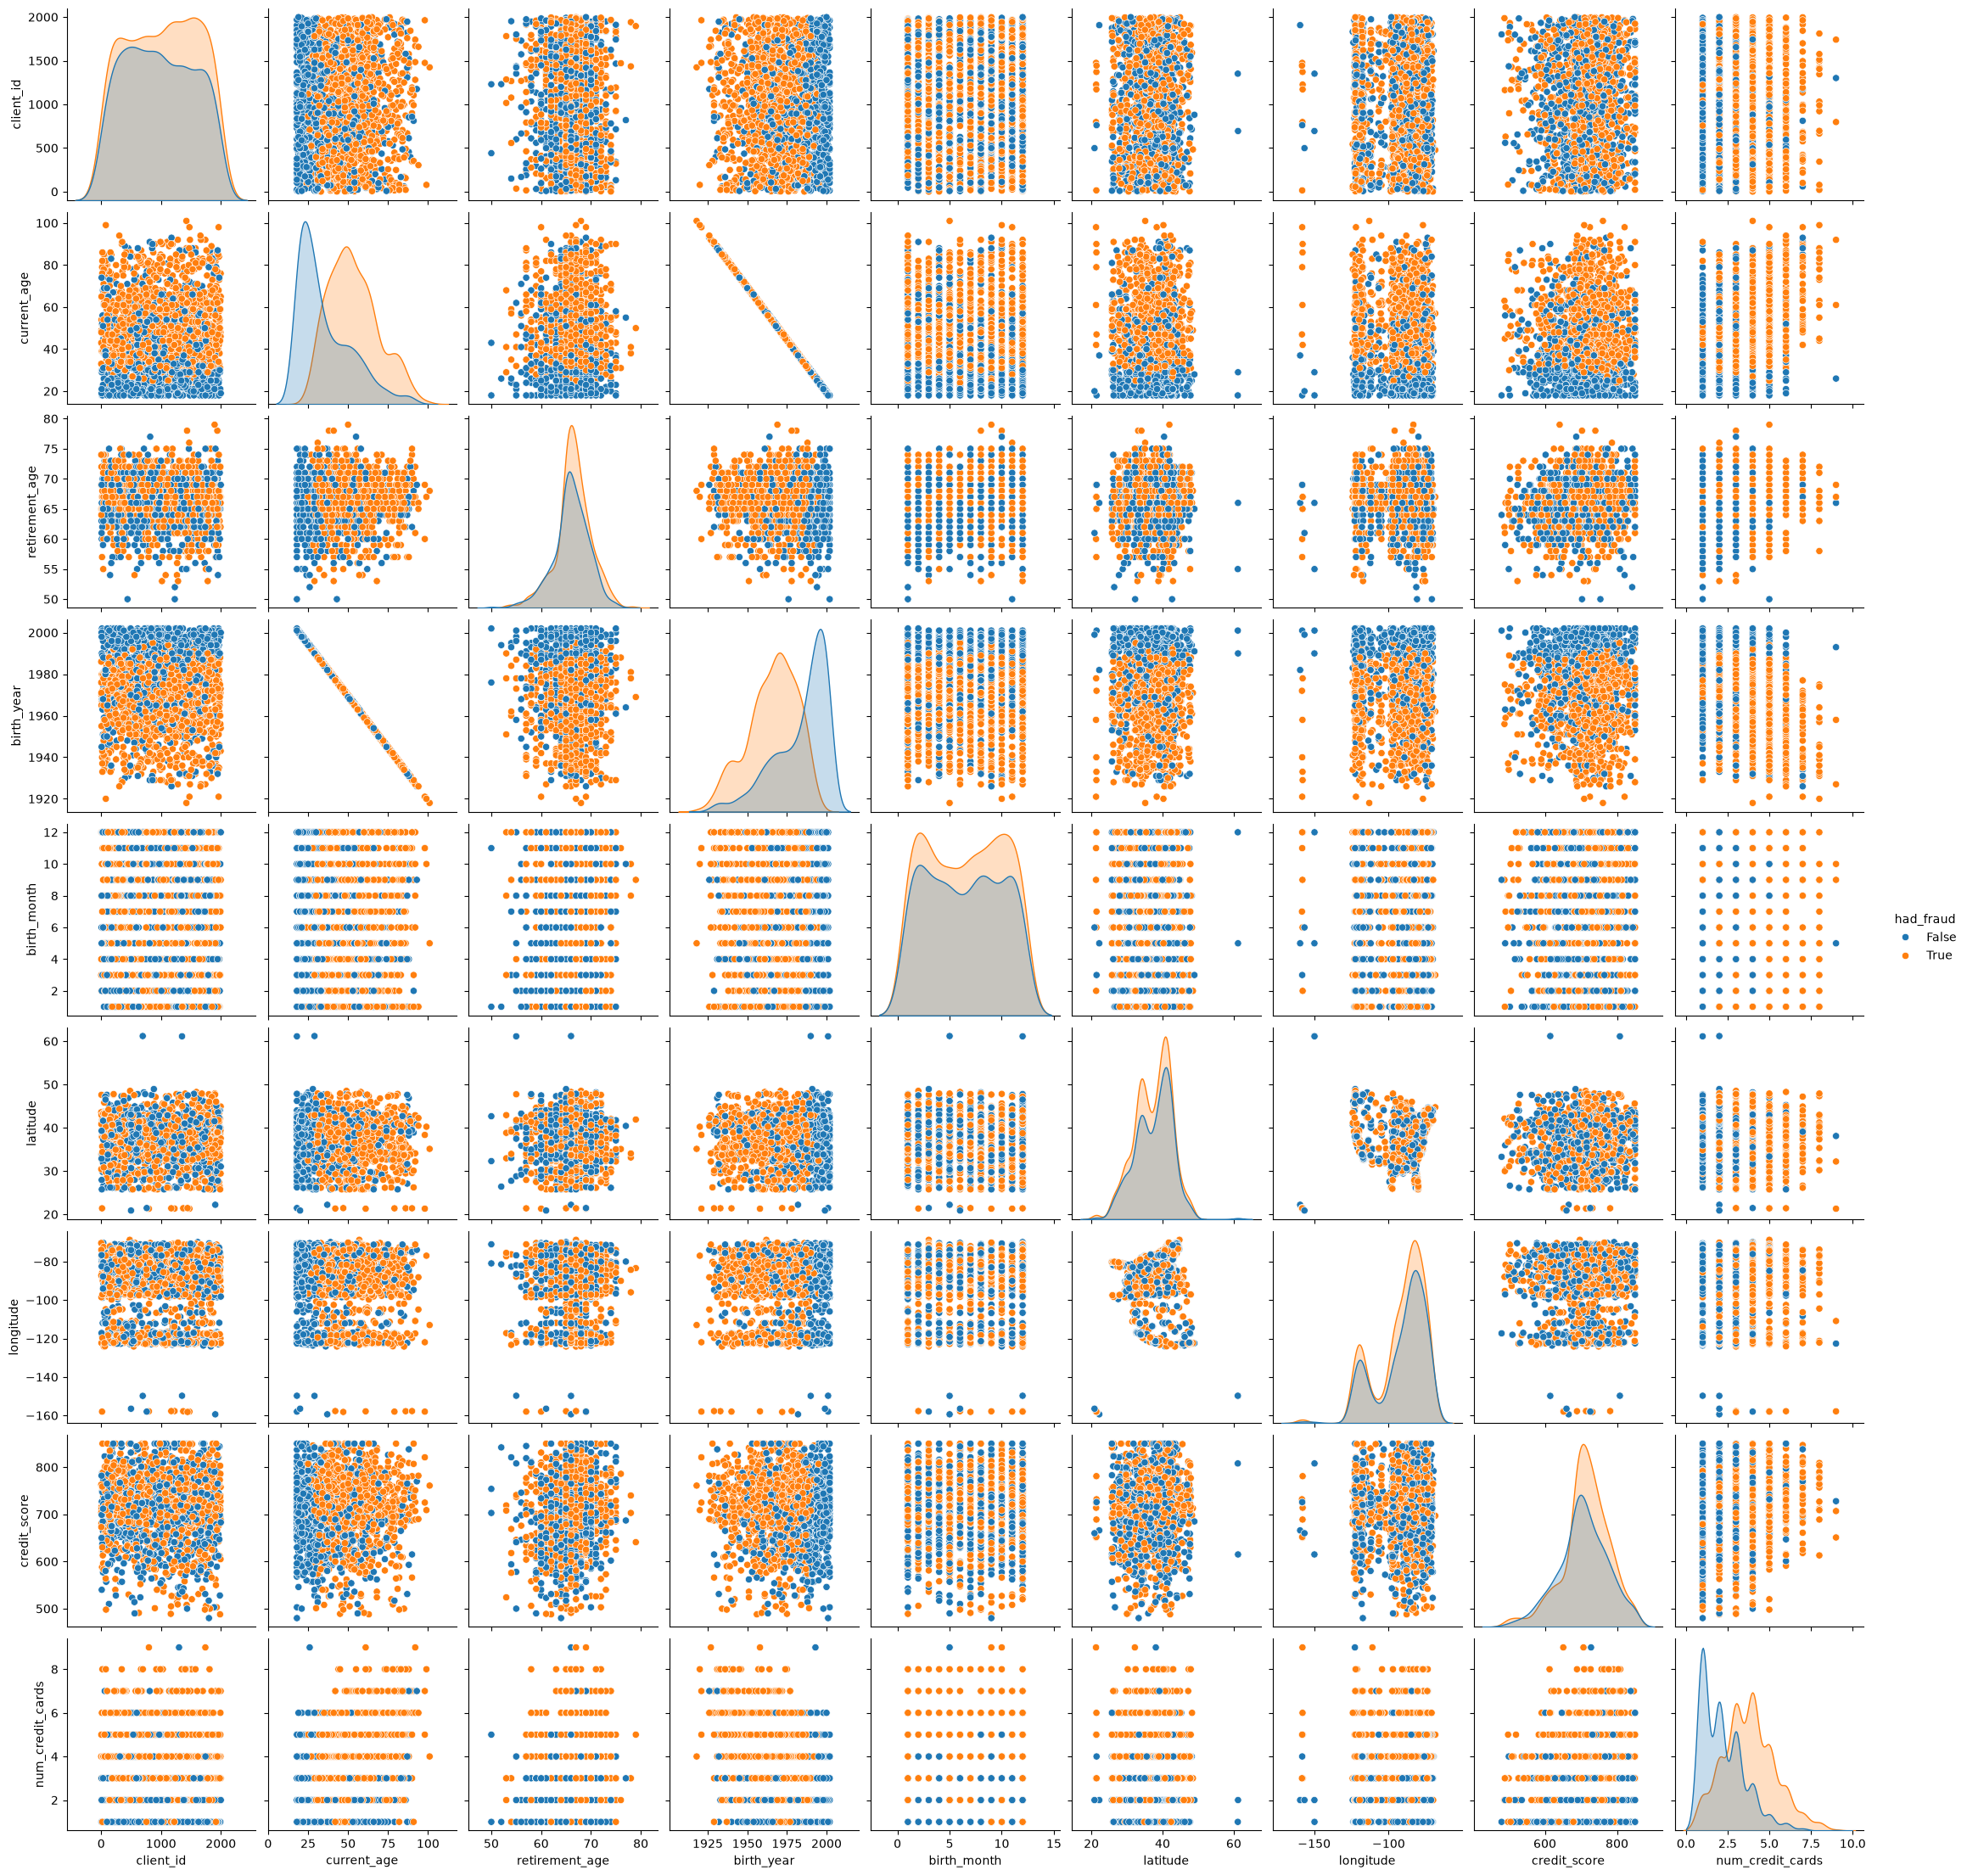

In [14]:
sns.pairplot(data=users_data, hue="had_fraud")

* num_credit_cards have different distributions for fraud positive and negative samples
* age also plays a vital role

<Axes: xlabel='current_age', ylabel='had_fraud'>

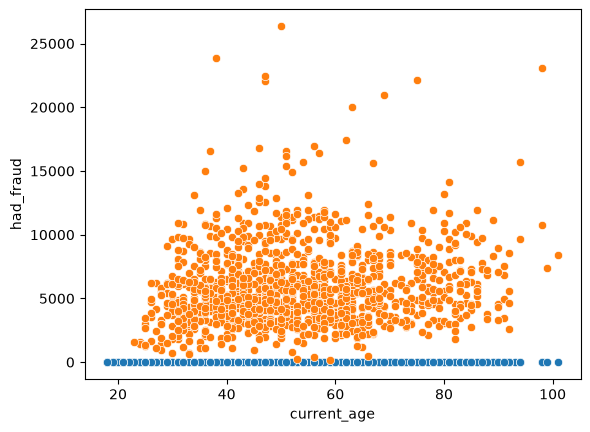

In [15]:
sns.scatterplot(data=users_data, x='current_age', y='had_fraud')
client_info_check = combined.groupby('client_id').agg(age=('current_age', 'first'),n_tx=('id', 'count'))
sns.scatterplot(data=client_info_check, x='age', y='n_tx')

<Axes: xlabel='age', ylabel='fraud_rate'>

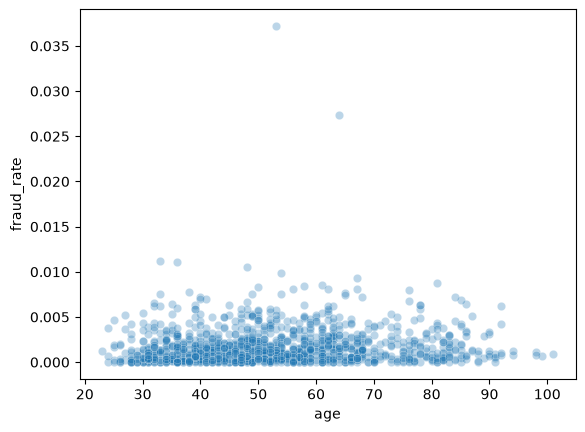

In [16]:
client_info_check['fraud_rate'] = combined.groupby('client_id')['target'].apply(lambda x: (x=='Yes').mean())
sns.scatterplot(data=client_info_check, x='age', y='fraud_rate', alpha=0.3)

* age is an artifact, because the more you have transactions the more you have chances to get a fraud at least once

<Axes: xlabel='target', ylabel='Count'>

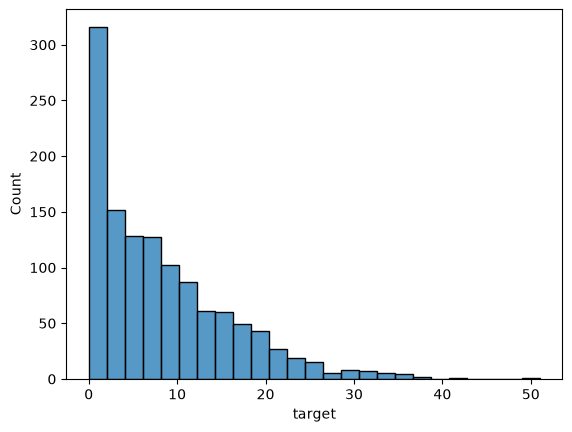

In [17]:
sns.histplot(data=combined_fraud, x="target")

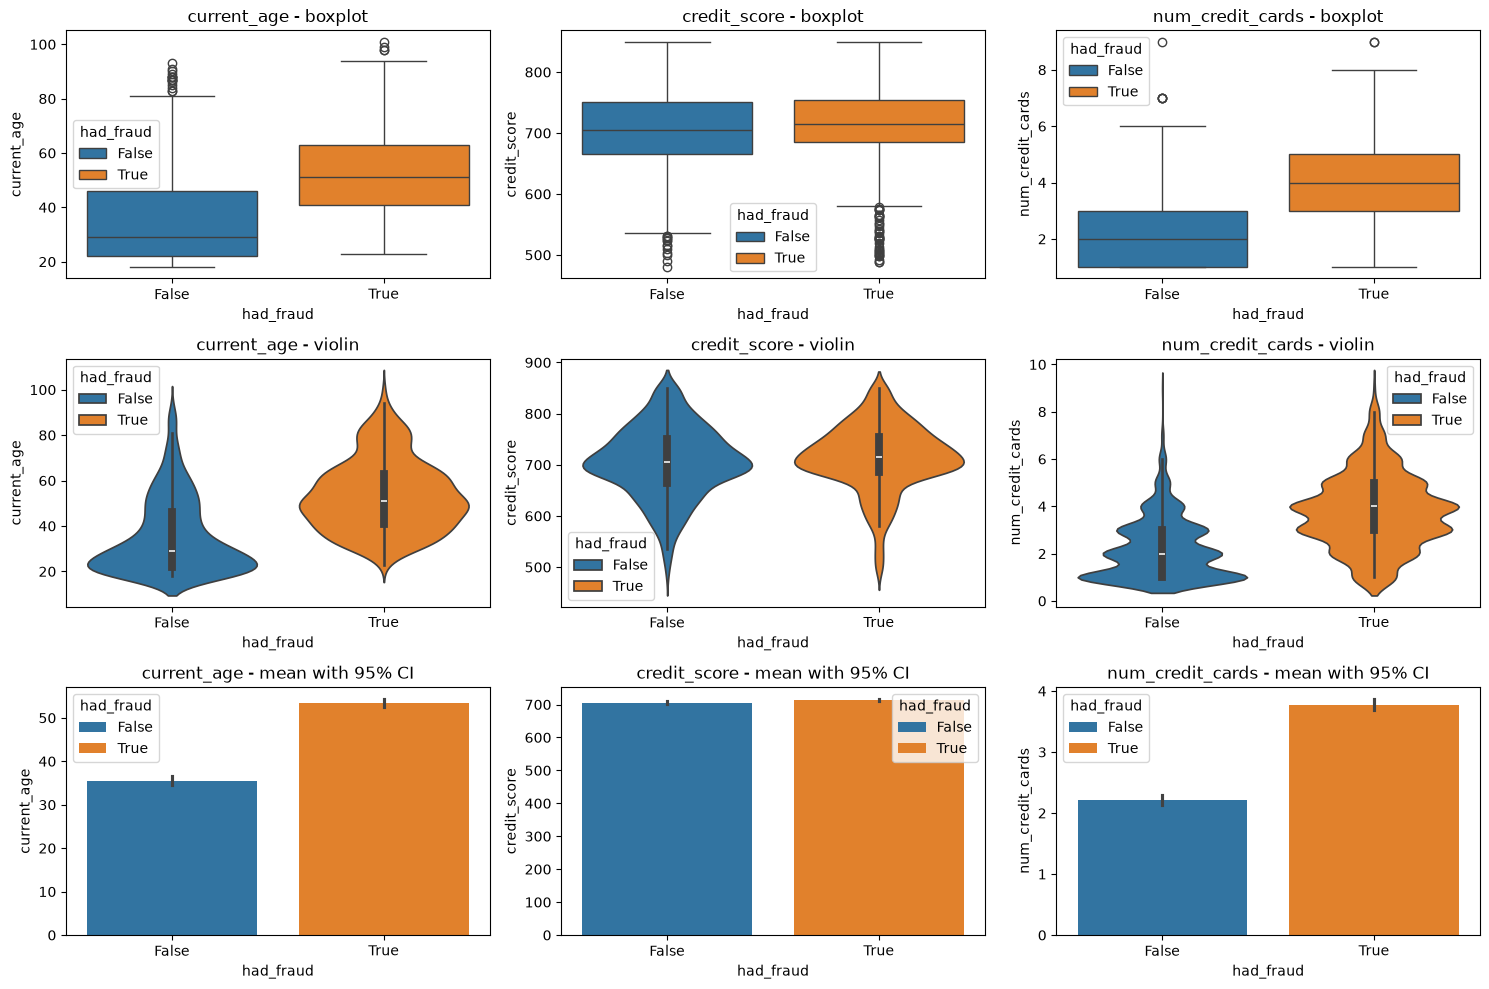

In [18]:
num_cols = ['current_age', 'credit_score', 'num_credit_cards']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(num_cols):
    # Boxplot
    sns.boxplot(data=users_data, x='had_fraud', hue="had_fraud",y=col, ax=axes[0, i])
    axes[0, i].set_title(f'{col} - boxplot')
    
    sns.violinplot(data=users_data, x='had_fraud', hue="had_fraud", y=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} - violin')
    
    sns.barplot(data=users_data, x='had_fraud', y=col, errorbar=('ci', 95),hue="had_fraud", ax=axes[2, i])
    axes[2, i].set_title(f'{col} - mean with 95% CI')

plt.tight_layout()
plt.show()

* we already defined, that age is an artifact now let§s check num credit cards

In [19]:
corr = users_data['current_age'].corr(users_data['num_credit_cards'], method='spearman')
print(f'Correlation between Age and credit cards count: {corr:.4f}')

Correlation between Age and credit cards count: 0.4664


<Axes: xlabel='num_credit_cards', ylabel='fraud_rate'>

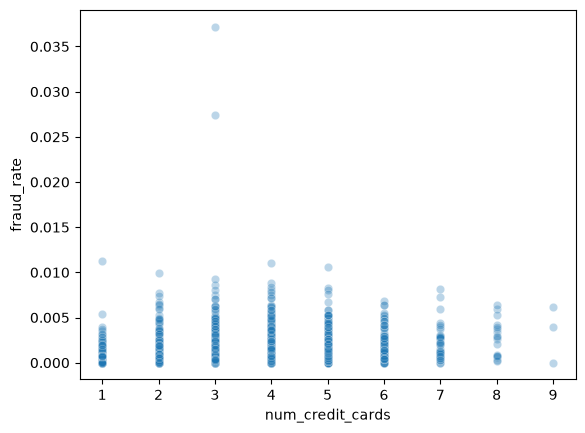

In [20]:
client_info_check = combined.groupby('client_id').agg(age=('current_age', 'first'),n_tx=('id', 'count'),num_credit_cards=('num_credit_cards', 'first'))
client_info_check['fraud_rate'] = combined.groupby('client_id')['target'].apply(lambda x: (x=='Yes').mean())

sns.scatterplot(data=client_info_check, x='num_credit_cards', y='fraud_rate', alpha=0.3)

* num_credit_cards also does not appear to be connected with the target

In [21]:
outliers = client_info_check[client_info_check['fraud_rate'] > 0.02]
print(outliers)
print(outliers['n_tx'])

           age  n_tx  num_credit_cards  fraud_rate
client_id                                         
1223        53   242                 3    0.037190
1649        64  1277                 3    0.027408
client_id
1223     242
1649    1277
Name: n_tx, dtype: int64


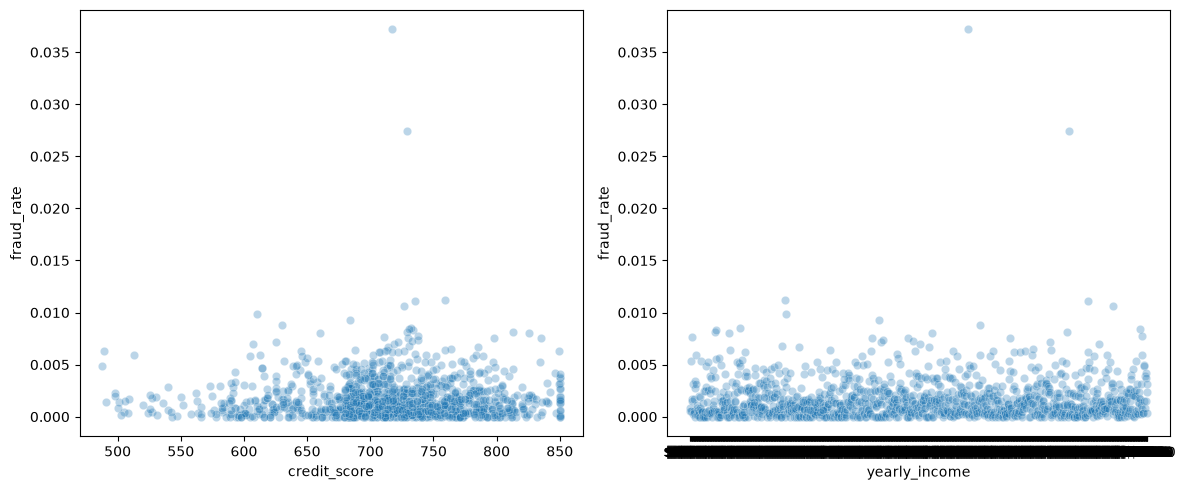

In [22]:
client_info_check['credit_score'] = combined.groupby('client_id')['credit_score'].first()
client_info_check['yearly_income'] = combined.groupby('client_id')['yearly_income'].first()
client_info_check['total_debt'] = combined.groupby('client_id')['total_debt'].first()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=client_info_check, x='credit_score', y='fraud_rate', alpha=0.3, ax=axes[0])
sns.scatterplot(data=client_info_check, x='yearly_income', y='fraud_rate', alpha=0.3, ax=axes[1])
plt.tight_layout()
plt.show()

In [23]:

for col in ['age', 'credit_score', 'yearly_income', 'num_credit_cards', 'total_debt']:
    corr, p = spearmanr(client_info_check[col], client_info_check['fraud_rate'])
    print(f'{col}: corr={corr:.4f}')

age: corr=0.1088
credit_score: corr=0.0274
yearly_income: corr=-0.0490
num_credit_cards: corr=0.1746
total_debt: corr=-0.0167


for the baseliine I will not use this dataset

### Check the location of transaction and users location

In [24]:
transactions_data

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,target
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,No
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,No
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,No
3,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,No
4,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7203020,20604841,2017-12-31 23:57:00,1024,4241,118.09,Chip Transaction,60569,Hillsboro,KS,67063.0,5300,NaN,No
7203021,20604842,2017-12-31 23:57:00,1945,4018,164.88,Swipe Transaction,16790,Los Angeles,CA,90017.0,3389,NaN,No
7203022,20604843,2017-12-31 23:58:00,273,5777,41.08,Chip Transaction,61195,Hubbard,OH,44425.0,5541,NaN,No
7203023,20604845,2017-12-31 23:59:00,273,5777,-79.00,Chip Transaction,61195,Hubbard,OH,44425.0,5541,NaN,No


In [25]:
combined

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.80,-100.76,$23679,$48277,$110153,740,4
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,6,Male,604 Pine Street,40.80,-91.12,$18076,$36853,$112139,834,5
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,4,Male,2379 Forest Lane,33.18,-117.29,$16894,$34449,$36540,686,3
3,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,...,5,Male,166 River Drive,38.86,-76.60,$33529,$68362,$96182,711,2
4,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,...,12,Female,14780 Plum Lane,40.84,-73.87,$25537,$52065,$98613,828,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7203020,20604841,2017-12-31 23:57:00,1024,4241,118.09,Chip Transaction,60569,Hillsboro,KS,67063.0,...,4,Male,554 Grant Boulevard,37.69,-97.13,$32162,$65573,$143069,739,4
7203021,20604842,2017-12-31 23:57:00,1945,4018,164.88,Swipe Transaction,16790,Los Angeles,CA,90017.0,...,2,Female,7728 Oak Drive,34.72,-92.35,$14736,$30042,$9208,727,4
7203022,20604843,2017-12-31 23:58:00,273,5777,41.08,Chip Transaction,61195,Hubbard,OH,44425.0,...,4,Female,849 Norfolk Lane,41.16,-80.56,$18351,$37415,$66403,665,1
7203023,20604845,2017-12-31 23:59:00,273,5777,-79.00,Chip Transaction,61195,Hubbard,OH,44425.0,...,4,Female,849 Norfolk Lane,41.16,-80.56,$18351,$37415,$66403,665,1


In [26]:
import pgeocode

nomi = pgeocode.Nominatim('us')

location_info = nomi.query_postal_code("58523") 
print(location_info.latitude, location_info.longitude)

47.2707 -101.8075


In [27]:
clean_zips = pd.to_numeric(combined["zip"], errors="coerce").fillna(0).astype(int).astype(str).str.zfill(5)

clean_zips = clean_zips.replace("00000", np.nan)
geo_df = nomi.query_postal_code(clean_zips.values)

combined["transaction_latitude"] = geo_df["latitude"]
combined["transaction_longitude"] = geo_df["longitude"]


In [28]:
combined

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,transaction_latitude,transaction_longitude
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,594 Mountain View Street,46.80,-100.76,$23679,$48277,$110153,740,4,47.2707,-101.8075
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,604 Pine Street,40.80,-91.12,$18076,$36853,$112139,834,5,41.5509,-90.4942
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,2379 Forest Lane,33.18,-117.29,$16894,$34449,$36540,686,3,33.2131,-117.2243
3,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,...,166 River Drive,38.86,-76.60,$33529,$68362,$96182,711,2,38.8582,-76.6145
4,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,...,14780 Plum Lane,40.84,-73.87,$25537,$52065,$98613,828,5,40.8469,-73.7874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7203020,20604841,2017-12-31 23:57:00,1024,4241,118.09,Chip Transaction,60569,Hillsboro,KS,67063.0,...,554 Grant Boulevard,37.69,-97.13,$32162,$65573,$143069,739,4,38.3449,-97.2122
7203021,20604842,2017-12-31 23:57:00,1945,4018,164.88,Swipe Transaction,16790,Los Angeles,CA,90017.0,...,7728 Oak Drive,34.72,-92.35,$14736,$30042,$9208,727,4,34.0559,-118.2666
7203022,20604843,2017-12-31 23:58:00,273,5777,41.08,Chip Transaction,61195,Hubbard,OH,44425.0,...,849 Norfolk Lane,41.16,-80.56,$18351,$37415,$66403,665,1,41.1624,-80.5762
7203023,20604845,2017-12-31 23:59:00,273,5777,-79.00,Chip Transaction,61195,Hubbard,OH,44425.0,...,849 Norfolk Lane,41.16,-80.56,$18351,$37415,$66403,665,1,41.1624,-80.5762


In [29]:

def haversine_vectorized(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c 
    return km

combined["distance_to_home_km"] = haversine_vectorized(combined["longitude"], combined["latitude"],combined["transaction_longitude"], combined["transaction_latitude"]    )
combined["location_type"] = np.where(combined["distance_to_home_km"] > 100, "Far (>100km)", "Close (<100km)")

In [30]:
combined

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,transaction_latitude,transaction_longitude,distance_to_home_km,location_type
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,-100.76,$23679,$48277,$110153,740,4,47.2707,-101.8075,95.024680,Close (<100km)
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,-91.12,$18076,$36853,$112139,834,5,41.5509,-90.4942,98.501994,Close (<100km)
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,-117.29,$16894,$34449,$36540,686,3,33.2131,-117.2243,7.131206,Close (<100km)
3,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,...,-76.60,$33529,$68362,$96182,711,2,38.8582,-76.6145,1.270560,Close (<100km)
4,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,...,-73.87,$25537,$52065,$98613,828,5,40.8469,-73.7874,6.986063,Close (<100km)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7203020,20604841,2017-12-31 23:57:00,1024,4241,118.09,Chip Transaction,60569,Hillsboro,KS,67063.0,...,-97.13,$32162,$65573,$143069,739,4,38.3449,-97.2122,73.130762,Close (<100km)
7203021,20604842,2017-12-31 23:57:00,1945,4018,164.88,Swipe Transaction,16790,Los Angeles,CA,90017.0,...,-92.35,$14736,$30042,$9208,727,4,34.0559,-118.2666,2371.224405,Far (>100km)
7203022,20604843,2017-12-31 23:58:00,273,5777,41.08,Chip Transaction,61195,Hubbard,OH,44425.0,...,-80.56,$18351,$37415,$66403,665,1,41.1624,-80.5762,1.381312,Close (<100km)
7203023,20604845,2017-12-31 23:59:00,273,5777,-79.00,Chip Transaction,61195,Hubbard,OH,44425.0,...,-80.56,$18351,$37415,$66403,665,1,41.1624,-80.5762,1.381312,Close (<100km)


In [ ]:
combined["target_numeric"] = (combined["target"].astype(str).str.lower() == "yes").astype(int)

sns.barplot(data=combined, x="use_chip", y="target_numeric", errorbar="ci")

TypeError: 'NoneType' object is not subscriptable

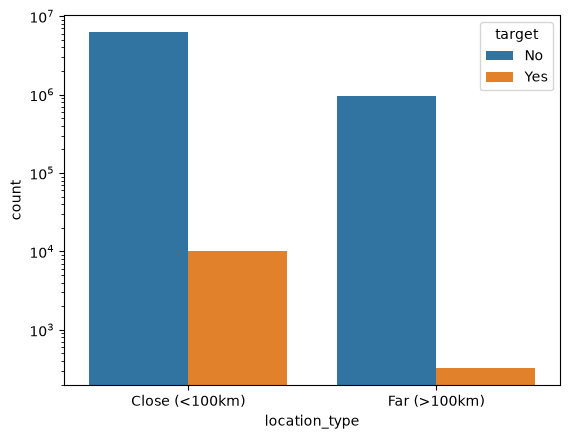

In [ ]:
sns.countplot(data = combined, x = "location_type", hue="target")
plt.yscale("log")

<Axes: ylabel='distance_to_home_km'>

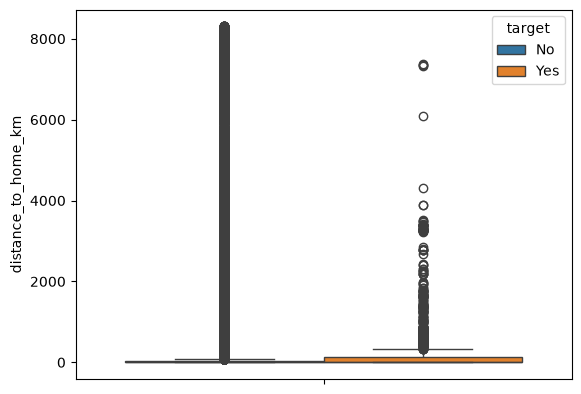

In [ ]:
sns.boxplot(data=combined, y="distance_to_home_km", hue="target")